In [1]:
import pandas as pd
train=pd.read_csv("BBC News Train - BBC News Train.csv")
train.head()

,ArticleId,Text,Category
0,1833,worldcom ex-boss launches defence lawyers defe...,business
1,154,german business confidence slides german busin...,business
2,1101,bbc poll indicates economic gloom citizens in ...,business
3,1976,lifestyle governs mobile choice faster bett...,tech
4,917,enron bosses in $168m payout eighteen former e...,business


In [2]:
train.shape

(1490, 3)

# Convert text into Lower and remove stopwords

In [3]:
import nltk
from nltk.corpus import stopwords
nltk.download("stopwords")
sw=stopwords.words("english")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sitar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\sitar\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [5]:
from nltk.tokenize import word_tokenize
def remove_stop_lower(text):
    retrained=[]
    words=word_tokenize(text)
    for word in words:
        if word not in sw:
            retrained.append(word)
    return " ".join(retrained)

In [6]:
train['Text']=train['Text'].apply(remove_stop_lower)

In [7]:
train['Text'].iloc[0]

'worldcom ex-boss launches defence lawyers defending former worldcom chief bernie ebbers battery fraud charges called company whistleblower first witness . cynthia cooper worldcom ex-head internal accounting alerted directors irregular accounting practices us telecoms giant 2002. warnings led collapse firm following discovery $ 11bn ( £5.7bn ) accounting fraud . mr ebbers pleaded guilty charges fraud conspiracy . prosecution lawyers argued mr ebbers orchestrated series accounting tricks worldcom ordering employees hide expenses inflate revenues meet wall street earnings estimates . ms cooper runs consulting business told jury new york wednesday external auditors arthur andersen approved worldcom accounting early 2001 2002. said andersen given green light procedures practices used worldcom . mr ebber lawyers said unaware fraud arguing auditors alert problems . ms cooper also said shareholder meetings mr ebbers often passed technical questions company finance chief giving brief answers .

# Removeing punctuation

In [8]:
import re
def remove_punc(text):
    text=re.sub(r'[^a-zA-Z0-9]',' ',text)
    return text

In [9]:
train['Text']=train['Text'].apply(remove_punc)

In [10]:
train['Text'].iloc[0]

'worldcom ex boss launches defence lawyers defending former worldcom chief bernie ebbers battery fraud charges called company whistleblower first witness   cynthia cooper worldcom ex head internal accounting alerted directors irregular accounting practices us telecoms giant 2002  warnings led collapse firm following discovery   11bn    5 7bn   accounting fraud   mr ebbers pleaded guilty charges fraud conspiracy   prosecution lawyers argued mr ebbers orchestrated series accounting tricks worldcom ordering employees hide expenses inflate revenues meet wall street earnings estimates   ms cooper runs consulting business told jury new york wednesday external auditors arthur andersen approved worldcom accounting early 2001 2002  said andersen given green light procedures practices used worldcom   mr ebber lawyers said unaware fraud arguing auditors alert problems   ms cooper also said shareholder meetings mr ebbers often passed technical questions company finance chief giving brief answers  

In [11]:
from nltk.stem import WordNetLemmatizer
wnl=WordNetLemmatizer()

In [12]:
def lem_word(text):
    lemm=[]
    words=word_tokenize(text)
    for word in words:
        lemm.append(wnl.lemmatize(word))
    return " ".join(lemm)

In [13]:
train['Text']=train['Text'].apply(lem_word)

In [14]:
train['Text'].iloc[0]

'worldcom ex bos launch defence lawyer defending former worldcom chief bernie ebbers battery fraud charge called company whistleblower first witness cynthia cooper worldcom ex head internal accounting alerted director irregular accounting practice u telecom giant 2002 warning led collapse firm following discovery 11bn 5 7bn accounting fraud mr ebbers pleaded guilty charge fraud conspiracy prosecution lawyer argued mr ebbers orchestrated series accounting trick worldcom ordering employee hide expense inflate revenue meet wall street earnings estimate m cooper run consulting business told jury new york wednesday external auditor arthur andersen approved worldcom accounting early 2001 2002 said andersen given green light procedure practice used worldcom mr ebber lawyer said unaware fraud arguing auditor alert problem m cooper also said shareholder meeting mr ebbers often passed technical question company finance chief giving brief answer prosecution star witness former worldcom financial 

In [15]:
x=train['Text']
y=train['Category']

# Splitting training and testing

In [16]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [17]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((1192,), (298,), (1192,), (298,))

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer
td=TfidfVectorizer()
x_train=td.fit_transform(x_train)
x_test=td.transform(x_test)

In [19]:
x_train[0]

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 142 stored elements and shape (1, 20147)>

In [20]:
x_test[0]

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 103 stored elements and shape (1, 20147)>

# Model predictions

In [21]:
from sklearn.naive_bayes import MultinomialNB
nb=MultinomialNB()
nb.fit(x_train,y_train)

MultinomialNB()

In [22]:
from sklearn.metrics import confusion_matrix,accuracy_score
acc = nb.score(x_test,y_test)

In [23]:
y_pred=nb.predict(x_test)

In [24]:
y_pred[:5]

array(['business', 'politics', 'politics', 'politics', 'sport'],
      dtype='<U13')

In [25]:
y_test[:5]

941    entertainment
297         politics
271         politics
774             tech
420             tech
Name: Category, dtype: object

In [26]:
cm=confusion_matrix(y_test,y_pred)

In [27]:
cm

array([[73,  0,  1,  0,  1],
       [ 1, 44,  1,  0,  0],
       [ 2,  0, 53,  1,  0],
       [ 0,  0,  0, 63,  0],
       [ 1,  0,  3,  1, 53]])

Text(50.722222222222214, 0.5, 'prediction values')

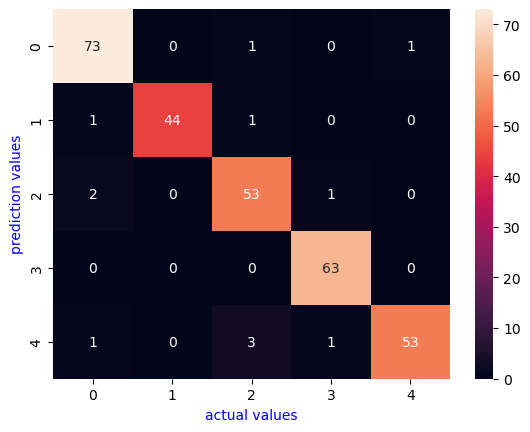

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel("actual values",color='blue')
plt.ylabel("prediction values",color='blue')

In [29]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(x_train,y_train)

LogisticRegression()

In [30]:
y_pred_lr=lr.predict(x_test)
y_pred_lr[:5]

array(['entertainment', 'politics', 'politics', 'tech', 'sport'],
      dtype=object)

In [31]:
acc_lr=lr.score(x_test,y_test)
acc_lr

0.9697986577181208

In [32]:
y_test[:5]

941    entertainment
297         politics
271         politics
774             tech
420             tech
Name: Category, dtype: object

In [33]:
cmm=confusion_matrix(y_test,y_pred)
cmm

array([[73,  0,  1,  0,  1],
       [ 1, 44,  1,  0,  0],
       [ 2,  0, 53,  1,  0],
       [ 0,  0,  0, 63,  0],
       [ 1,  0,  3,  1, 53]])

In [34]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()
dt.fit(x_train,y_train)

DecisionTreeClassifier()

In [35]:
acc_dt=dt.score(x_test,y_test)
acc_dt

0.8389261744966443

In [36]:
y_pred_dt=dt.predict(x_test)
y_pred_dt[:5]

array(['entertainment', 'politics', 'politics', 'politics', 'business'],
      dtype=object)

In [37]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

acc_rf = rf.score(x_test, y_test)
acc_rf

0.9664429530201343

In [38]:
y_pred_rf[:5]

array(['entertainment', 'politics', 'politics', 'tech', 'tech'],
      dtype=object)

In [39]:
predictions=pd.DataFrame({"Models":["Naive_bayes","Logistic_reg","Decision_tree","Random_forest"],
                          "Accuracy":[acc,acc_lr,acc_dt,acc_rf]})
predictions

,Models,Accuracy
0,Naive_bayes,0.959732
1,Logistic_reg,0.969799
2,Decision_tree,0.838926
3,Random_forest,0.966443


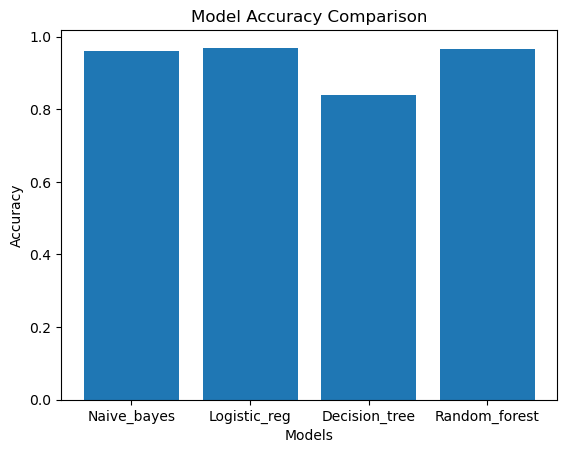

In [40]:
plt.bar(predictions["Models"], predictions["Accuracy"])
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()